In [1]:
%pip install transformers datasets torch numpy scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
from datasets import load_dataset
from transformers import RobertaTokenizer
from datasets import Sequence, Value
import torch
import numpy as np

# 1. Load goEmotions Dataset and get Sentiment Labels
goEmotionsDataset = load_dataset('go_emotions')
sentimentLabels = goEmotionsDataset['train'].features['labels'].feature.names

# 2. one-hot encoding
def one_hot_encode(example):
    vector = np.zeros(28, dtype=np.float32)
    for label_index in example['labels']:
        vector[label_index] = 1.0
    return {'labels': vector}

dataset = goEmotionsDataset.map(one_hot_encode)

# 3. Tokenize and format for PyTorch (Using ONLY the Tokenizer)
def tokenize_text(rows):
    return tokenizer(rows['text'], padding='max_length', truncation=True, max_length=128)

tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
tokenized_dataset = dataset.map(tokenize_text, batched=True)
tokenized_dataset = tokenized_dataset.cast_column("labels", Sequence(Value("float32")))
tokenized_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

# 4. Calculate Class Weights for the CNN's Loss Function
train_labels = np.array(tokenized_dataset['train']['labels'])
pos_counts = np.sum(train_labels, axis=0)
neg_counts = len(train_labels) - pos_counts
pos_weight_calc = neg_counts / (pos_counts + 1e-6)
pos_weight_tensor = torch.tensor(pos_weight_calc, dtype=torch.float)

print("Data processing complete. Ready for CNN architecture!")

/Users/donovanchen/UCI/CS175/RedditSentimentAnalysis/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Casting the dataset: 100%|██████████| 5427/5427 [00:00<00:00, 1354748.71 examples/s]


Data processing complete. Ready for CNN architecture!


In [3]:
import torch.nn as nn

class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes, kernel_sizes=[3, 4, 5], num_filters=100):
        super(TextCNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        
        # 2. Convolutional Layers
        self.convs = nn.ModuleList([
            nn.Conv2d(in_channels=1, out_channels=num_filters, kernel_size=(k, embed_dim)) 
            for k in kernel_sizes
        ])
        
        # 3. Dropout: prevent overfitting
        self.dropout = nn.Dropout(0.5)
        
        # 4. Maps features to the 28 emotion classes
        self.fc = nn.Linear(len(kernel_sizes) * num_filters, num_classes)

    def forward(self, x):
        x = self.embedding(x).unsqueeze(1)
        
        # Apply convolution, ReLU activation, spatial dimension
        x = [torch.relu(conv(x)).squeeze(3) for conv in self.convs] 
        
        # Apply Max Pooling
        x = [torch.max_pool1d(i, i.size(2)).squeeze(2) for i in x] 
        
        # Concatenate the results
        x = torch.cat(x, 1)
        x = self.dropout(x)
        
        # Output raw logits for the 28 classes
        logits = self.fc(x)
        return logits

In [5]:
from torch.utils.data import DataLoader, TensorDataset

batch_size = 32

def create_dataloader(split_name):
    # Extract input_ids and labels from your tokenized dataset
    input_ids = torch.tensor(tokenized_dataset[split_name]['input_ids'])
    labels = torch.tensor(tokenized_dataset[split_name]['labels'])
    
    # Create a TensorDataset and DataLoader
    dataset = TensorDataset(input_ids, labels)
    
    # We only shuffle the training data; validation and testing should stay in order
    return DataLoader(dataset, batch_size=batch_size, shuffle=(split_name == 'train'))

train_loader = DataLoader(tokenized_dataset['train'], batch_size=batch_size, shuffle=True)
val_loader = DataLoader(tokenized_dataset['validation'], batch_size=batch_size, shuffle=False)
test_loader = DataLoader(tokenized_dataset['test'], batch_size=batch_size, shuffle=False)

print("DataLoaders created successfully.")

DataLoaders created successfully.


In [ ]:
import torch.optim as optim
from tqdm import tqdm

vocab_size = tokenizer.vocab_size
embed_dim = 128
num_classes = 28 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cnn_model = TextCNN(vocab_size, embed_dim, num_classes).to(device)

optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)

pos_weight_tensor = pos_weight_tensor.to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

# Training Loop
num_epochs = 4

print(f"Starting Training on {device}...")
for epoch in range(num_epochs):
    cnn_model.train()
    total_loss = 0
    
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
    
    for batch in progress_bar:
        batch_inputs = batch['input_ids'].to(device)
        batch_labels = batch['labels'].to(device)
        
        optimizer.zero_grad()
        
        # Forward pass
        logits = cnn_model(batch_inputs)
        
        # Calculate weighted loss
        loss = criterion(logits, batch_labels.float())
        
        # Backward pass and optimize
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
        # Update progress bar
        progress_bar.set_postfix({'loss': loss.item()})
        
    avg_train_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1} Complete | Average Training Loss: {avg_train_loss:.4f}")
    
# Save the model weights
torch.save(cnn_model.state_dict(), './.saved_models/cnn_emotion_model.pth')
print("Model saved")

Starting Training on cpu...


Epoch 1/4: 100%|██████████| 1357/1357 [00:30<00:00, 44.96it/s, loss=1.13] 


Epoch 1 Complete | Average Training Loss: 1.3357


Epoch 2/4: 100%|██████████| 1357/1357 [00:32<00:00, 42.31it/s, loss=1.64] 


Epoch 2 Complete | Average Training Loss: 1.1158


Epoch 3/4: 100%|██████████| 1357/1357 [00:31<00:00, 42.58it/s, loss=0.909]


Epoch 3 Complete | Average Training Loss: 0.9629


Epoch 4/4: 100%|██████████| 1357/1357 [00:34<00:00, 39.71it/s, loss=0.831]


Epoch 4 Complete | Average Training Loss: 0.8511
Model saved to cnn_emotion_model.pth


In [ ]:
import time
import numpy as np
from sklearn.metrics import classification_report

# Evaluation and Latency Test

cnn_model.eval()

all_predictions = []
all_true_labels = []

print("Starting CNN Evaluation on Test Set...")
start_time = time.time()

with torch.no_grad():
    for batch in test_loader:
        batch_inputs = batch['input_ids'].to(device)
        batch_labels = batch['labels'].numpy()
        
        logits = cnn_model(batch_inputs)
        
        probs = torch.sigmoid(logits).cpu().numpy()
        
        all_predictions.extend(probs)
        all_true_labels.extend(batch_labels)

end_time = time.time()
total_time = end_time - start_time
num_samples = len(all_predictions)

# Latency Results
print(f"Processed {num_samples} samples in {total_time:.2f} seconds.")
print(f"CNN Average Latency: {(total_time / num_samples) * 1000:.2f} milliseconds per post.")

Starting CNN Evaluation on Test Set...
Processed 5427 samples in 0.96 seconds.
CNN Average Latency: 0.18 milliseconds per post.


In [23]:
def optimize_cnn_thresholds(val_probs, val_true):
    best_thresholds = []
    
    # Iterate over all 28 emotion classes
    for i in range(28):
        best_t = 0.5
        best_f1 = 0.0
        
        # Check thresholds from 0.1 to 0.95 in steps of 0.05
        for t in np.arange(0.1, 0.95, 0.05):
            preds = (val_probs[:, i] >= t).astype(int)
            score = f1_score(val_true[:, i], preds, zero_division=0)
            
            if score > best_f1:
                best_f1 = score
                best_t = t
                
        best_thresholds.append(best_t)
        
    return np.array(best_thresholds)

# Run the optimization
optimal_cnn_thresholds = optimize_cnn_thresholds(val_predictions, val_true_labels)

print("Optimal CNN Thresholds per class:")
for name, thresh in zip(sentimentLabels, optimal_cnn_thresholds):
    print(f"{name}: {thresh:.2f}")

Optimal CNN Thresholds per class:
admiration: 0.70
amusement: 0.85
anger: 0.80
annoyance: 0.60
approval: 0.55
caring: 0.80
confusion: 0.75
curiosity: 0.90
desire: 0.90
disappointment: 0.60
disapproval: 0.70
disgust: 0.90
embarrassment: 0.90
excitement: 0.90
fear: 0.90
gratitude: 0.90
grief: 0.90
joy: 0.85
love: 0.85
nervousness: 0.90
optimism: 0.80
pride: 0.90
realization: 0.70
relief: 0.85
remorse: 0.90
sadness: 0.90
surprise: 0.75
neutral: 0.40


In [25]:
# 3 Buckets Test

sentimentMap = {
  "positive": ["admiration", "amusement", "approval", "caring", "desire", "excitement", "gratitude", "joy", "love", "optimism", "pride", "relief"],
  "negative": ["anger", "annoyance", "disappointment", "disapproval", "disgust", "embarrassment", "fear", "grief", "nervousness", "remorse", "sadness"],
  "neutral": ["neutral", "realization", "surprise", "curiosity", "confusion"]
}

pos_indices = [sentimentLabels.index(e) for e in sentimentMap['positive'] if e in sentimentLabels]
neg_indices = [sentimentLabels.index(e) for e in sentimentMap['negative'] if e in sentimentLabels]
neu_indices = [sentimentLabels.index(e) for e in sentimentMap['neutral'] if e in sentimentLabels]

def get_bucket_preds(probability_matrix):
    bucket_preds = []
    for row in probability_matrix:
        pos_score = np.sum(row[pos_indices])
        neg_score = np.sum(row[neg_indices])
        neu_score = np.sum(row[neu_indices])
        # 0=Positive, 1=Negative, 2=Neutral
        bucket_preds.append(np.argmax([pos_score, neg_score, neu_score]))
    return bucket_preds

y_true_buckets_cnn = get_bucket_preds(all_true_labels)
y_pred_buckets_cnn = get_bucket_preds(all_predictions)

print("\nTextCNN Final Evaluation (Mapped to 3 Buckets):")
print("-" * 50)
print(classification_report(
    y_true_buckets_cnn,
    y_pred_buckets_cnn,
    target_names=['Positive', 'Negative', 'Neutral']
))


TextCNN Final Evaluation (Mapped to 3 Buckets):
--------------------------------------------------
              precision    recall  f1-score   support

    Positive       0.63      0.74      0.68      2098
    Negative       0.36      0.79      0.49      1182
     Neutral       0.79      0.15      0.25      2147

    accuracy                           0.51      5427
   macro avg       0.59      0.56      0.47      5427
weighted avg       0.63      0.51      0.47      5427



In [14]:
from sklearn.metrics import f1_score
import numpy as np
import torch

cnn_model.eval()

val_predictions = []
val_true_labels = []

print("Running Validation Set for Threshold Optimization...")

with torch.no_grad():
    for batch in val_loader:
        batch_inputs = batch['input_ids'].to(device)
        batch_labels = batch['labels'].numpy()
        
        logits = cnn_model(batch_inputs)
        probs = torch.sigmoid(logits).cpu().numpy()
        
        val_predictions.extend(probs)
        val_true_labels.extend(batch_labels)

val_predictions = np.array(val_predictions)
val_true_labels = np.array(val_true_labels)
print("Validation predictions complete!")

Running Validation Set for Threshold Optimization...
Validation predictions complete!


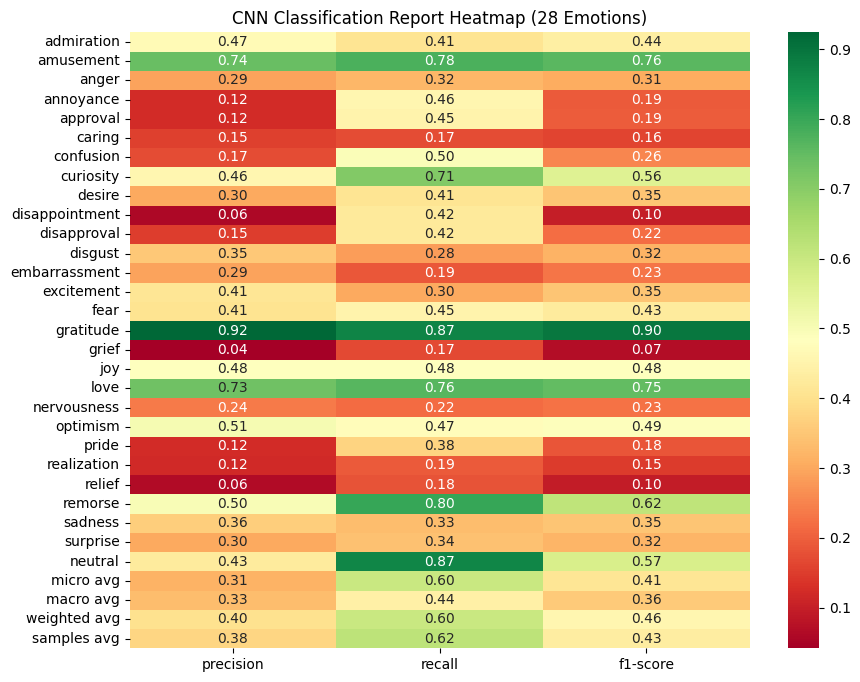

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

binary_predictions = (np.array(all_predictions) >= optimal_cnn_thresholds).astype(int)
true_labels_array = np.array(all_true_labels)


# classification report as a dictionary
report_dict = classification_report(
    true_labels_array, 
    binary_predictions, 
    target_names=sentimentLabels, 
    output_dict=True, 
    zero_division=0
)

report_df = pd.DataFrame(report_dict).iloc[:-1, :].T

# 3. Plot the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(report_df, annot=True, cmap='RdYlGn', fmt='.2f')
plt.title("CNN Classification Report Heatmap (28 Emotions)")
plt.show()

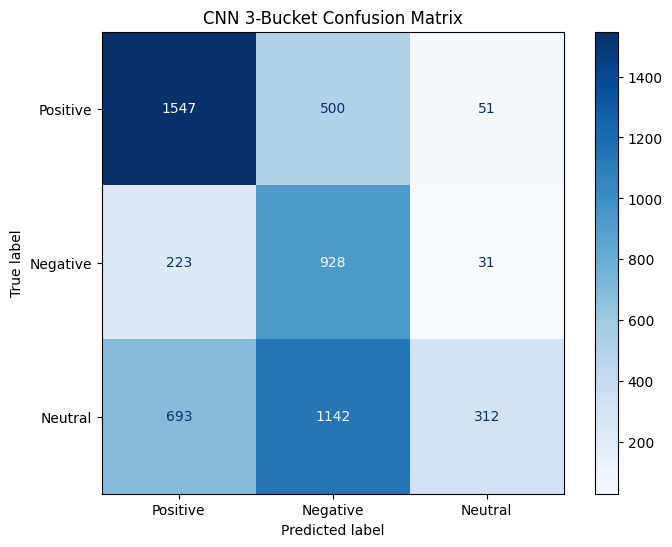

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 3 Bucket Confusion Matrix
cm_3_bucket = confusion_matrix(y_true_buckets_cnn, y_pred_buckets_cnn)

fig, ax = plt.subplots(figsize=(8, 6))
cmd = ConfusionMatrixDisplay(
    confusion_matrix=cm_3_bucket, 
    display_labels=['Positive', 'Negative', 'Neutral']
)

cmd.plot(cmap='Blues', ax=ax, values_format='d')
plt.title("CNN 3-Bucket Confusion Matrix")
plt.show()

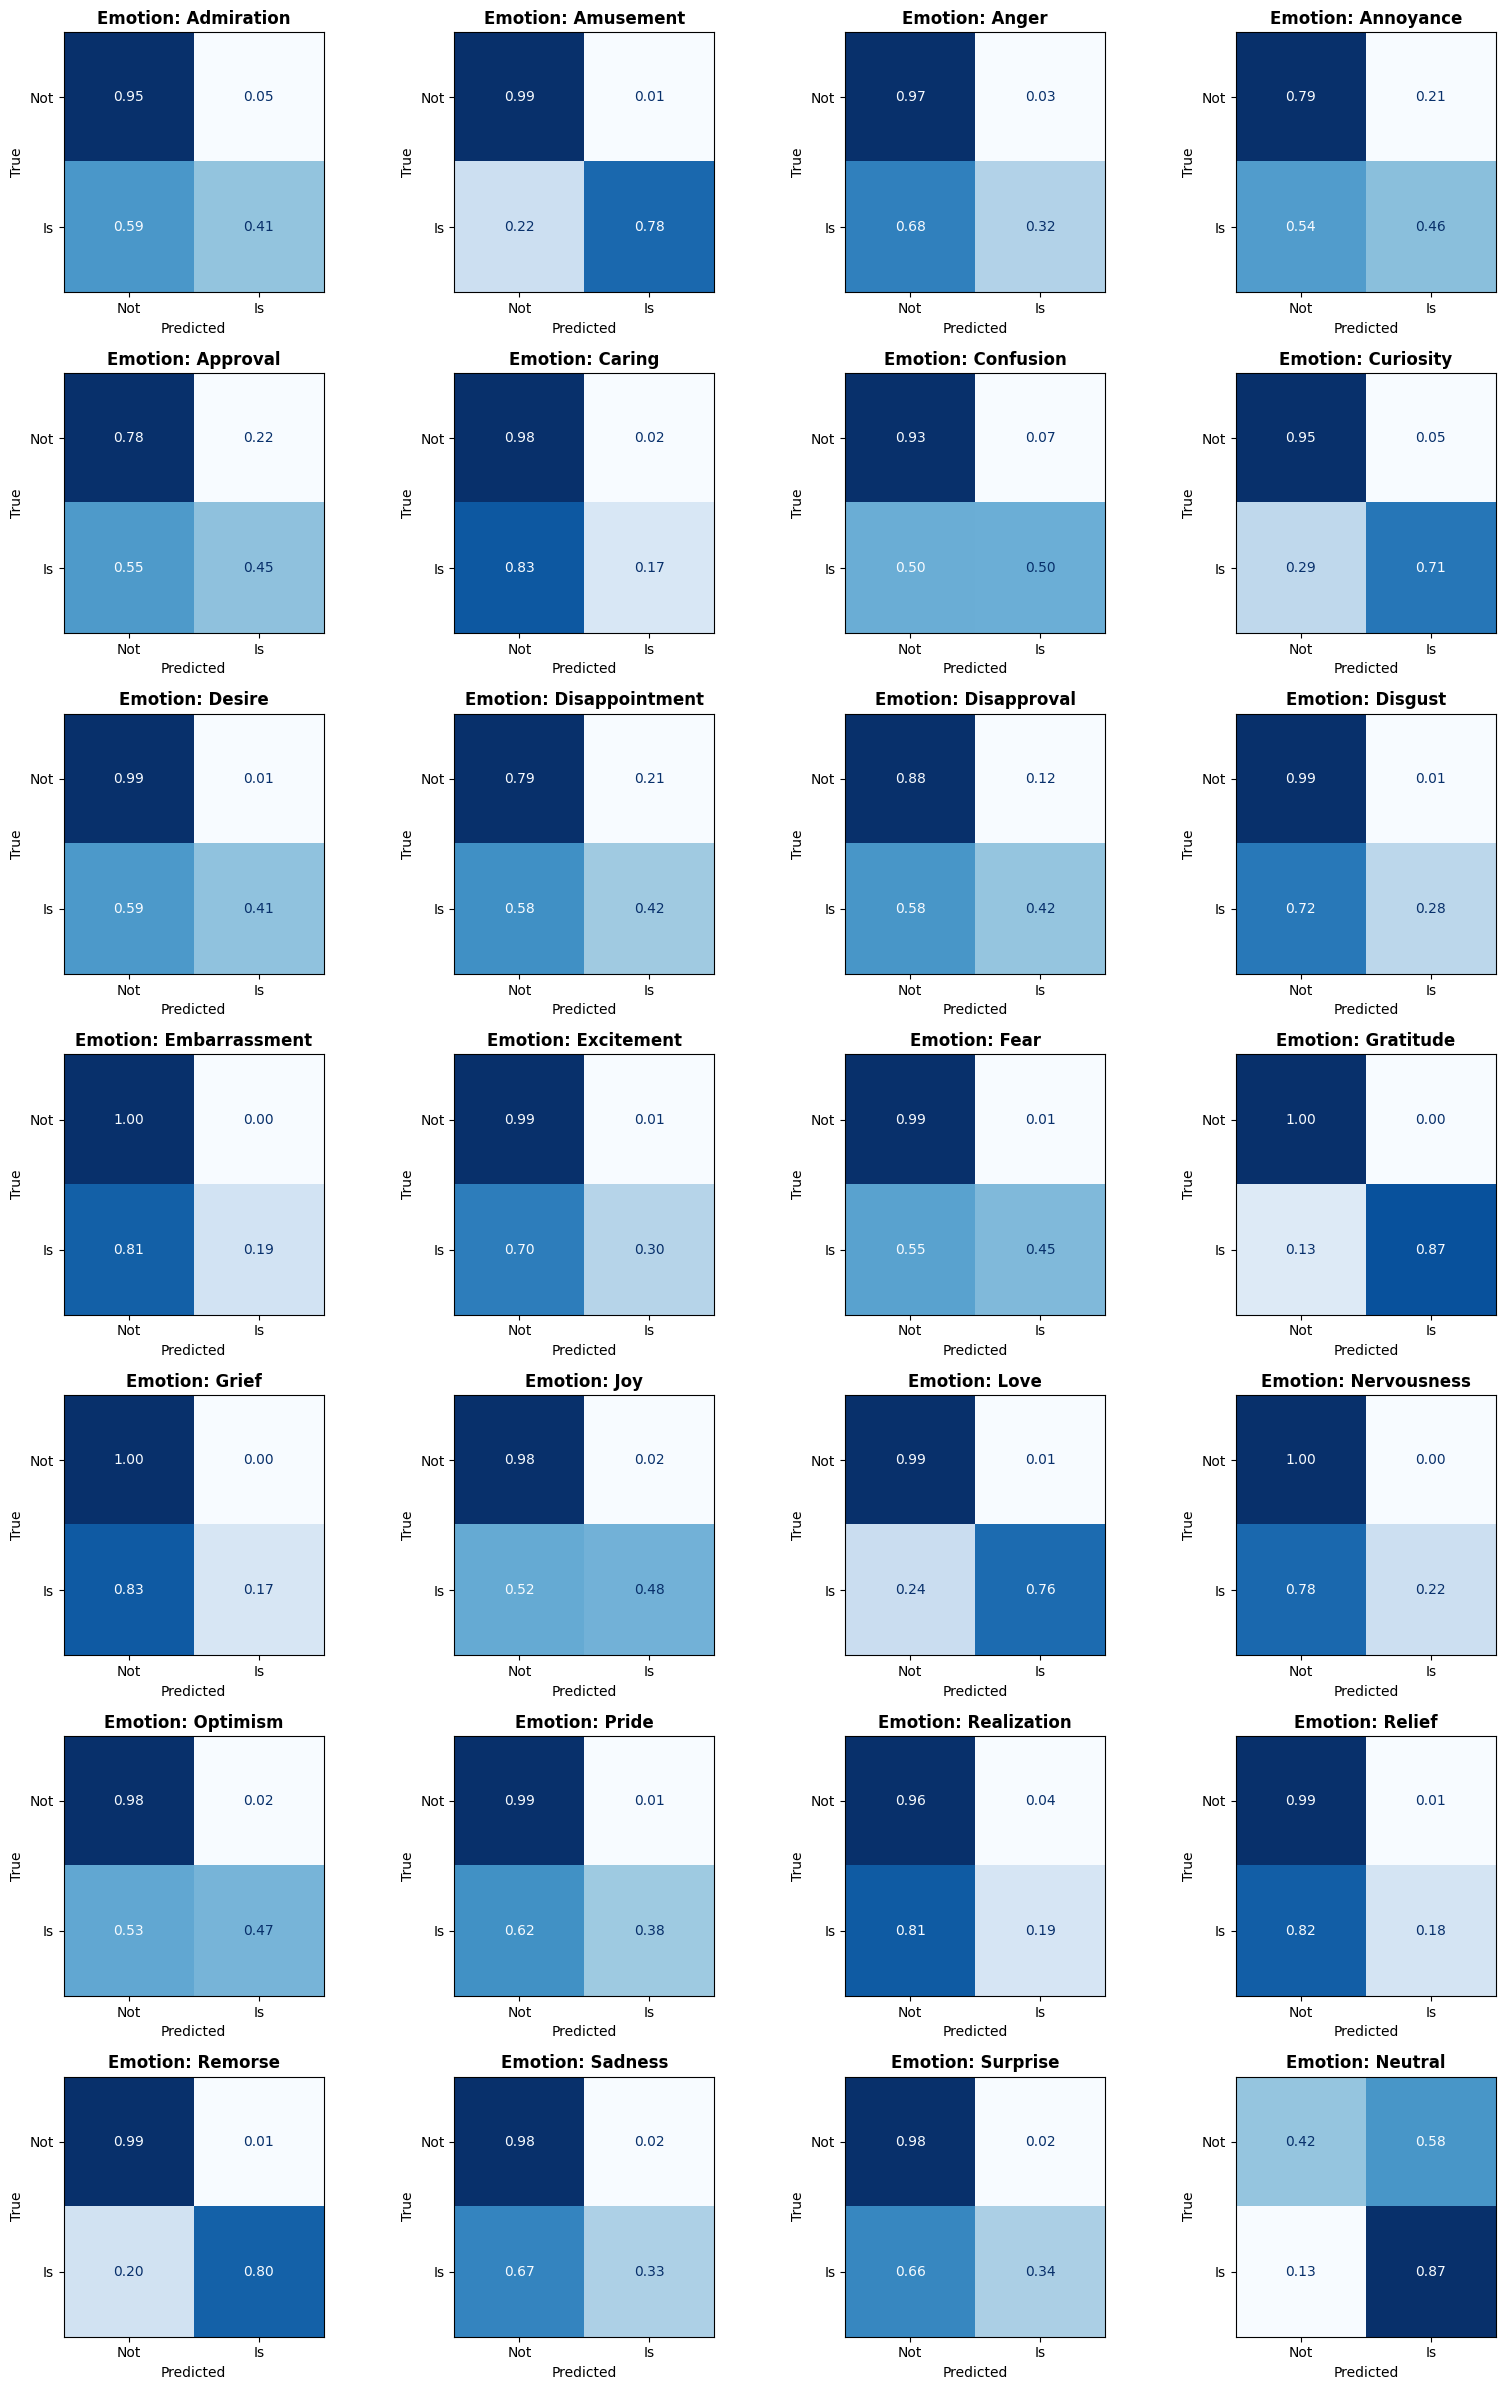

In [22]:
from sklearn.metrics import multilabel_confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# 28 Emotions Confusion Matrix

mcm = multilabel_confusion_matrix(true_labels_array, binary_predictions)

fig, axes = plt.subplots(7, 4, figsize=(16, 24))
axes = axes.ravel() 

for i, (emotion_name, matrix) in enumerate(zip(sentimentLabels, mcm)):
    
    row_sums = matrix.sum(axis=1)
    
    matrix_normalized = np.divide(
        matrix.astype('float'), 
        row_sums[:, np.newaxis], 
        out=np.zeros_like(matrix, dtype=float), 
        where=row_sums[:, np.newaxis]!=0
    )
    
    disp = ConfusionMatrixDisplay(confusion_matrix=matrix_normalized, display_labels=['Not', 'Is'])
    
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False, values_format='.2f')
    
    axes[i].set_title(f"Emotion: {emotion_name.capitalize()}", fontweight='bold')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('True')

plt.tight_layout()
plt.show()